In [181]:
import requests
from IPython.core.display import HTML
# HTML(f"""
# <style>
# @import "https://cdn.jsdelivr.net/npm/bulma@0.9.4/css/bulma.min.css";
# </style>
# """)

# Model selection and descriptive statistics
In this exercise, you are given noisy data and methods to fit polynomial models multiple times to different subsets of the data. Your task is to use descriptive statistics (such as mean, variance, covariance, and correlation) to analyze the performance of these models and reflect on how well they fit the data. You will investigate how
- the models capture the underlying data 
- the fit varies across different subsets of training data
- assess how well the models perform on unseen data.

## Functions and libraries
The cell below contains functions for generating a noisy dataset and fitting a polynomial multiple times to different subsets of the generated data. More specifically:
1. `generate_polynomial(x, coeffs)`
: Generates ground truth data from the underlying function for a polynomial given the coefficients.
2. `add_gaussian_noise(y, mean, variance, num_outliers)`
: Adds Gaussian noise with a specified **mean** and **variance** and a number of outliers (`num_outliers`
) to simulate noisy data.
3. `fit_polynomial(x, y, M, N)`
: Samples  $M$  random points  $(x, y)$ from the dataset and fits an $N$-th order polynomial to the points. The function returns the fitted coefficients and the mean squared error (MSE) of the fit.
4. `iterate_fit(x, y, M, N, K)`
: Performs the polynomial fitting $K$ times, each time sampling  $M$  points  $(x, y)$  and fitting a polynomial of order $N$. The method returns the mean and variance of the MSE fits of each iteration, the mean of the fitted coefficients, and their covariance and correlation matrices.

## Model Fitting

---
**Task 1 (easy): Fitting the models👩‍💻**
1. Run the cells below to create the inputs `x_range`
 and the noisy outputs `y_noisy`

2. Use the `iterate_fit()`
 function to fit a 2nd-order polynomial to the generated inputs and outputs. Fit the model 100 times, sampling 20 points as the training data in each iteration.


---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Function to generate polynomial values
def generate_polynomial(x, coeffs):
    return np.polyval(coeffs, x)

# Function to add Gaussian noise and outliers
def add_gaussian_noise(y, mean, variance, num_outliers):
    noisy_y = y + np.random.normal(mean, np.sqrt(variance), len(y))
    
    # Add outliers
    outlier_indices = np.random.choice(range(len(noisy_y)), size=num_outliers, replace=False)
    for idx in outlier_indices:
        noisy_y[idx] += 10 * variance  # Adding large variance to simulate outliers
    
    return noisy_y

# Function to sample M points and fit a polynomial of order N
def fit_polynomial(x, y, M, N):
    # Randomly sample M points from the dataset
    indices = np.random.choice(len(x), M, replace=False)
    x_sampled = x[indices]
    y_sampled = y[indices]
    
    # Fit a polynomial of order N to the sampled points
    coeffs = np.polyfit(x_sampled, y_sampled, N)
    fitted_poly = np.poly1d(coeffs)
    
    # Calculate loss (mean squared error)
    y_fitted = fitted_poly(x_sampled)
    mse = np.mean((y_sampled - y_fitted) ** 2)
    
    return mse, coeffs


# Function to iterate K times, fit the model and compute mean/variance of errors and params
def iterate_fit(x, y, M, N, K):
    errors = []
    coeffs_list = []
    
    for _ in range(K):
        mse, coeffs = fit_polynomial(x, y, M, N)
        errors.append(mse)
        coeffs_list.append(coeffs)
    
    # Convert lists to arrays for easier manipulation
    errors = np.array(errors)
    coeffs_array = np.array(coeffs_list)
    
    # Compute statistics
    error_mean = np.mean(errors)
    error_variance = np.var(errors, ddof=1)
    coeffs_mean = np.mean(coeffs_array, axis=0)
    coeffs_covariance = np.cov(coeffs_array, rowvar=False)
    coeffs_correlation = np.corrcoef(coeffs_array, rowvar=False)
    
    return errors, coeffs_array, error_mean, error_variance, coeffs_mean, coeffs_covariance, coeffs_correlation

# Function for plotting, to prepare error bars
def prepare_error_bars(means, variances):
    std = np.sqrt(variances)
    lower_bound = np.maximum(0, np.array(means) - std)
    upper_bound = np.array(means) + std
    return [np.array(means) - lower_bound, upper_bound - np.array(means)]

In [183]:
# Parameters for the dataset
coefficients = [1, -2, 3]  # Coefficients for the polynomial (change as needed)
x_range = np.linspace(-10, 10, 100)  # Range of x values
mean = 0  # Mean for the Gaussian noise
variance = 50  # Variance for the Gaussian noise
num_outliers = 5  # Number of outliers to introduce

# Generate noise-free polynomial dataset
y_clean = generate_polynomial(x_range, coefficients)

# Generate dataset with Gaussian noise and outliers
y_noisy = add_gaussian_noise(y_clean, mean, variance, num_outliers)

# Write your code here
M = 20  # Number of points to sample as training data in each iteration
N = 2   # Order of the polynomial to fit
K = 100 # Number of iterations
iteration_results = iterate_fit(x_range, y_noisy, M, N, K)
errors, coeffs_array, error_mean, error_variance, coeffs_mean, coeffs_covariance, coeffs_correlation = iteration_results


---
**Task 2 (medium): Plotting the results👩‍💻💡📽️**
1. Run the cell below to display the fitted polynomial models and the mean fitted polynomial over the noisy data.

2. What does the variability of the fitted polynomials say about the complexity of the underlying function?

3. Repeat the model fitting process with the same parameters as before, but using noisy data with 5 and 15 outliers. 

4. Compare the results of having 0, 5 and 15 outliers. How do the outliers impact the variability of the individual models and the mean fitted polynomial?

5. Repeat the model fitting process with the same parameter as before, but set the number of outliers to 0 and adjust the noise variance to 150 and then to 650. 

6. How is the mean fitted polynomial affected by the increase in the noise variance? Does noise affect the model similarly to outliers? 



---

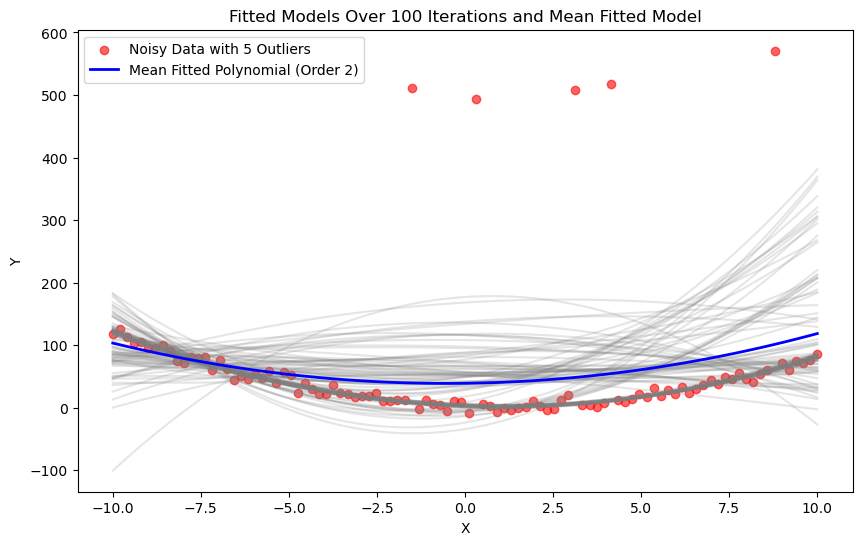

In [ ]:
# Plot all fitted models and the mean fitted polynomial
plt.figure(figsize=(10, 6))
plt.scatter(x_range, y_noisy, label=f'Noisy Data with {num_outliers} Outliers', color='red', alpha=0.6)

# Plot all fitted models from the iterations
for i in range(K):
    fitted_poly = np.poly1d(coeffs_array[i])
    plt.plot(x_range, fitted_poly(x_range), color='gray', alpha=0.2)

# Plot the mean fitted polynomial
fitted_mean_poly = np.poly1d(coeffs_mean)
plt.plot(x_range, fitted_mean_poly(x_range), label=f'Mean Fitted Polynomial (Order {N})', color='blue', linewidth=2)

plt.title(f"Fitted Models Over {K} Iterations and Mean Fitted Model")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [ ]:
# Write your reflections here...
# The plot above display the fitted polynomial models and the mean fitted polynomial over the noisy data.

# 2. What does the variability of the fitted polynomials say about the complexity of the underlying function?
# The variability of the fitted polynomials indicates how well the model is able to capture the underlying function.
# It indicates whether the chosen model complexity is appropriate, but it does not directly measure the complexity of the true underlying function.
# If the function is more complex than the chosen model, we may see more variability in the fitted models as they attempt to capture the nuances of the data, which are too complex for the model to represent.
# And if the function is simpler than the chosen model, we may also see high variability as the model overfits to noise and outliers in the data instead of capturing the true underlying function.
# But if the model complexity matches the underlying function complexity, the fitted models will likely show less variability and converge more closely to a single solution.

# That said, even if the complexity of the model is appropriate, high variability may still occur due to noise and outliers in the data.


# 3. Repeat the model fitting process with the same parameters as before, but using noisy data with 5 and 15 outliers. 
# See below. (Since we already have 5 outliers, the below code shows the results after using data with 0 and 15 outliers.)


In [187]:
# 0 outliers:
num_outliers = 0  # Number of outliers to introduce
y_noisy = add_gaussian_noise(y_clean, mean, variance, num_outliers) # Generate dataset with Gaussian noise and 10 outliers
errors, coeffs_array, error_mean, error_variance, coeffs_mean, coeffs_covariance, coeffs_correlation = iterate_fit(x_range, y_noisy, M, N, K)

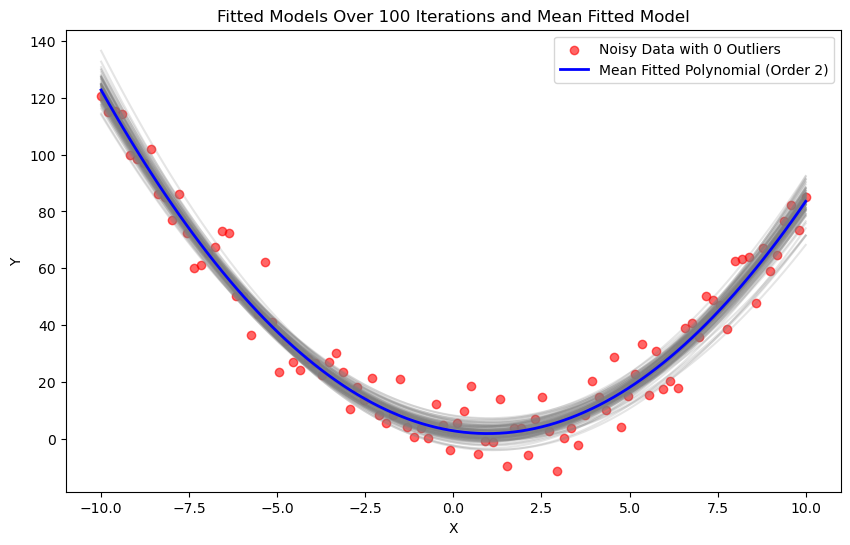

In [ ]:
# Plot all fitted models and the mean fitted polynomial
plt.figure(figsize=(10, 6))
plt.scatter(x_range, y_noisy, label=f'Noisy Data with {num_outliers} Outliers', color='red', alpha=0.6)

# Plot all fitted models from the iterations
for i in range(K):
    fitted_poly = np.poly1d(coeffs_array[i])
    plt.plot(x_range, fitted_poly(x_range), color='gray', alpha=0.2)

# Plot the mean fitted polynomial
fitted_mean_poly = np.poly1d(coeffs_mean)
plt.plot(x_range, fitted_mean_poly(x_range), label=f'Mean Fitted Polynomial (Order {N})', color='blue', linewidth=2)

plt.title(f"Fitted Models Over {K} Iterations and Mean Fitted Model")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

print("Accuracy without outliers:")

In [189]:
# 15 outliers:
num_outliers = 15  # Number of outliers to introduce
y_noisy = add_gaussian_noise(y_clean, mean, variance, num_outliers) # Generate dataset with Gaussian noise and 10 outliers
errors, coeffs_array, error_mean, error_variance, coeffs_mean, coeffs_covariance, coeffs_correlation = iterate_fit(x_range, y_noisy, M, N, K)

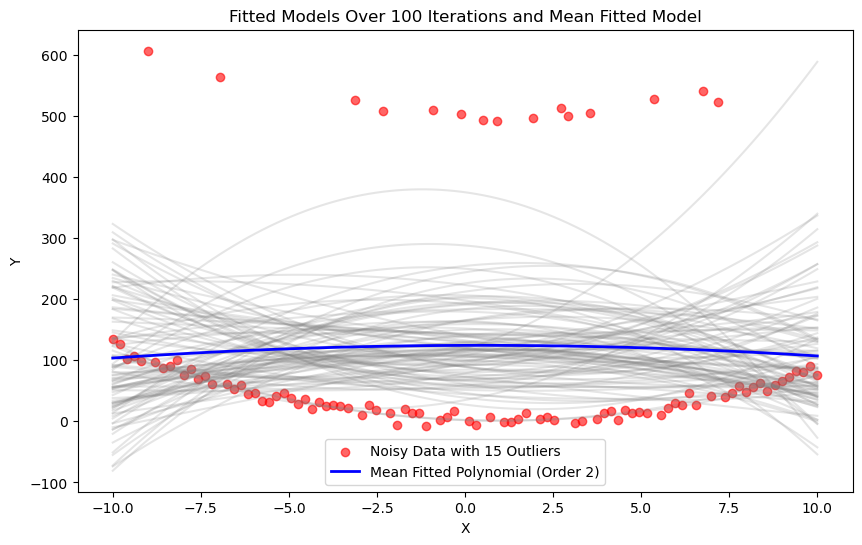

In [190]:
# Plot all fitted models and the mean fitted polynomial
plt.figure(figsize=(10, 6))
plt.scatter(x_range, y_noisy, label=f'Noisy Data with {num_outliers} Outliers', color='red', alpha=0.6)

# Plot all fitted models from the iterations
for i in range(K):
    fitted_poly = np.poly1d(coeffs_array[i])
    plt.plot(x_range, fitted_poly(x_range), color='gray', alpha=0.2)

# Plot the mean fitted polynomial
fitted_mean_poly = np.poly1d(coeffs_mean)
plt.plot(x_range, fitted_mean_poly(x_range), label=f'Mean Fitted Polynomial (Order {N})', color='blue', linewidth=2)

plt.title(f"Fitted Models Over {K} Iterations and Mean Fitted Model")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [ ]:
# Write your reflection here

# The above plots shows the results of repeating the model fitting process with the same parameters as before, but using noisy data with 0 and 15 outliers instead of 5. 

# 4. Compare the results of having 0, 5 and 15 outliers. How do the outliers impact the variability of the individual models and the mean fitted polynomial?
# The presence of outliers significantly impacts the variability of the individual models and the mean fitted polynomial.
# With 0 outliers, the fitted models are more consistent and closely follow the underlying polynomial function.
# As the number of outliers increases to 5 and then to 15, the variability among the fitted models increases noticeably.
# The individual models become more erratic, attempting to fit the outliers, which leads to a wider spread of fitted polynomials.
# The mean fitted polynomial also deviates more from the true underlying function as the number of outliers increases, indicating that outliers can skew the overall fit and reduce the model's accuracy.

# 5. Repeat the model fitting process with the same parameter as before, but set the number of outliers to 0 and adjust the noise variance to 150 and then to 650. 
# See below.


In [192]:
num_outliers = 0  # Number of outliers to introduce

variance = 150  # Variance for the Gaussian noise
y_noisy = add_gaussian_noise(y_clean, mean, variance, num_outliers) # Generate dataset with Gaussian noise and outliers
errors, coeffs_array, error_mean, error_variance, coeffs_mean, coeffs_covariance, coeffs_correlation = iterate_fit(x_range, y_noisy, M, N, K)

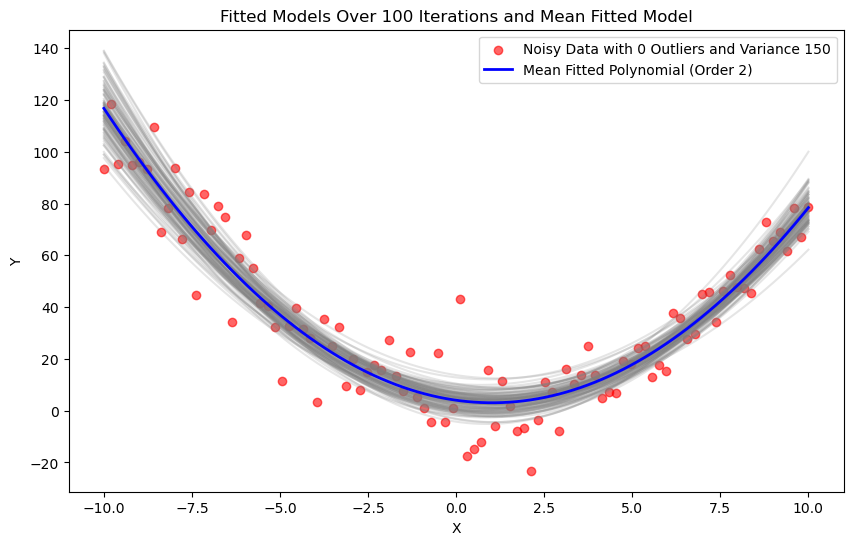

In [193]:
# Plot all fitted models and the mean fitted polynomial
plt.figure(figsize=(10, 6))
plt.scatter(x_range, y_noisy, label=f'Noisy Data with {num_outliers} Outliers and Variance {variance}', color='red', alpha=0.6)

# Plot all fitted models from the iterations
for i in range(K):
    fitted_poly = np.poly1d(coeffs_array[i])
    plt.plot(x_range, fitted_poly(x_range), color='gray', alpha=0.2)

# Plot the mean fitted polynomial
fitted_mean_poly = np.poly1d(coeffs_mean)
plt.plot(x_range, fitted_mean_poly(x_range), label=f'Mean Fitted Polynomial (Order {N})', color='blue', linewidth=2)

plt.title(f"Fitted Models Over {K} Iterations and Mean Fitted Model")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [194]:

variance = 650  # Variance for the Gaussian noise
y_noisy = add_gaussian_noise(y_clean, mean, variance, num_outliers) # Generate dataset with Gaussian noise and outliers
errors, coeffs_array, error_mean, error_variance, coeffs_mean, coeffs_covariance, coeffs_correlation = iterate_fit(x_range, y_noisy, M, N, K)

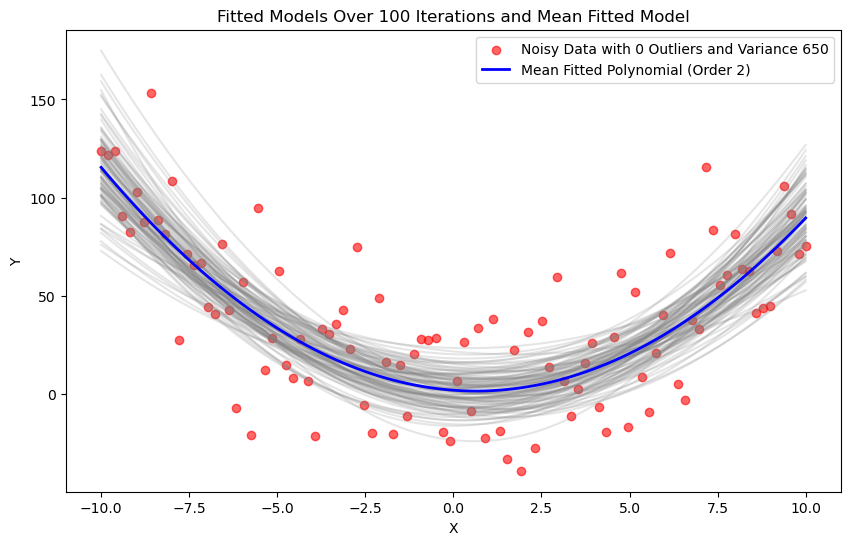

In [195]:
# Plot all fitted models and the mean fitted polynomial
plt.figure(figsize=(10, 6))
plt.scatter(x_range, y_noisy, label=f'Noisy Data with {num_outliers} Outliers and Variance {variance}', color='red', alpha=0.6)

# Plot all fitted models from the iterations
for i in range(K):
    fitted_poly = np.poly1d(coeffs_array[i])
    plt.plot(x_range, fitted_poly(x_range), color='gray', alpha=0.2)

# Plot the mean fitted polynomial
fitted_mean_poly = np.poly1d(coeffs_mean)
plt.plot(x_range, fitted_mean_poly(x_range), label=f'Mean Fitted Polynomial (Order {N})', color='blue', linewidth=2)

plt.title(f"Fitted Models Over {K} Iterations and Mean Fitted Model")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [ ]:
#The plots above show the results of repeating the model fitting process with the same parameters as before, but setting the number of outliers to 0 and adjusting the noise variance to 150 and then to 650 instead of 50.

# 6. How is the mean fitted polynomial affected by the increase in the noise variance? Does noise affect the model similarly to outliers? 
# Higher noise variance introduces more randomness into the data, making it harder for the model to capture the true relationship. 
# This results in greater variability among the fitted models, but as iterations increase, the mean fitted polynomial tends to stabilize around the underlying function.
# While both noise and outliers affect the model, they do so in different ways.
# Outliers can have a more pronounced effect by skewing the fitted models significantly, especially when they are extreme values. 
# We say the mean fit becomes biased toward outlier locations. Even rare outliers can shift the mean noticeably and bias does *not* vanish with more repetitions.
# In contrast, increased noise variance generally leads to a more uniform degradation of model accuracy, affecting the overall fit rather than causing abrupt deviations.


## Generalizability

---
**Task 3 (medium): Test set MSE👩‍💻**
The following task will modify the `fit_polynomial()`
 and the `iterate_fit()`
 functions to test the model's performance on unseen data.
1. Modify the `fit_polynomial()`
 function:    
 - Uncomment the line under `# Comment1`
 to create a test set and read the documentation on  [`np.setdiff1d()`
](https://numpy.org/doc/2.0/reference/generated/numpy.setdiff1d.htmls)
 - Compute `y_fitted_test`
 by applying the polynomial model to the inputs in the test set.
 - Calculate the mean squared error (MSE) for the model’s predictions on the test data and store it in `mse_test`.


2. Modify the `iterate_fit()`
 function:    
 - Calculate the mean (`error_mean_test`
) and variance (`error_variance_test`
) of the test errors and let the function return these values. 


3. Generate noisy outputs with the variance of the Gaussian noise set to $100$ and no outliers. 
4. Use the generated data to fit a 2nd-order polynomial using  `iterate_fit()`
. Fit the model 100 times, sampling 20 points in each iteration.


---

In [221]:
# 1.

def fit_polynomial(x, y, M, N):
    # Randomly sample M points from the dataset for training
    indices = np.random.choice(len(x), M, replace=False)
    x_sampled = x[indices]
    y_sampled = y[indices]
    
    # Use the remaining points as the test set
    # Comment1
    test_indices = np.setdiff1d(np.arange(len(x)), indices) # finds all indices in the first array (all indices) that are not in the second array (sampled indices).
    x_test = x[test_indices]
    y_test = y[test_indices]

    
    # Fit a polynomial of order N to the sampled points
    coeffs = np.polyfit(x_sampled, y_sampled, N)
    fitted_poly = np.poly1d(coeffs)
    
    # Calculate training loss (mean squared error) on the sampled points
    y_fitted_train = fitted_poly(x_sampled)
    mse_train = np.mean((y_sampled - y_fitted_train) ** 2)
    
    # Calculate test loss (mean squared error) on the remaining points (unseen data)
    y_fitted_test = fitted_poly(x_test)
    mse_test = np.mean((y_test - y_fitted_test) ** 2)

    return mse_train, mse_test, coeffs


# 2. 
def iterate_fit(x, y, M, N, K):
    errors_train = []
    errors_test = []
    coeffs_list = []
    
    for _ in range(K):
        # Get both training and test errors from fit_polynomial
        mse_train, mse_test, coeffs = fit_polynomial(x, y, M, N)
        errors_train.append(mse_train)
        errors_test.append(mse_test)
        coeffs_list.append(coeffs)
    
    # Convert lists to arrays for easier manipulation
    errors_train = np.array(errors_train)
    errors_test = np.array(errors_test)
    coeffs_array = np.array(coeffs_list)
    
    # Compute statistics for training errors
    error_mean_train = np.mean(errors_train)
    error_variance_train = np.var(errors_train, ddof=1)
    
    # Compute statistics for test errors
    error_mean_test = np.mean(errors_test)
    error_variance_test = np.var(errors_test, ddof=1)

    # Compute coefficient statistics
    coeffs_mean = np.mean(coeffs_array, axis=0)
    coeffs_covariance = np.cov(coeffs_array, rowvar=False)
    coeffs_correlation = np.corrcoef(coeffs_array, rowvar=False)
    
    return (errors_train, errors_test, coeffs_array, 
            error_mean_train, error_variance_train, 
            error_mean_test, error_variance_test, 
            coeffs_mean, coeffs_covariance, coeffs_correlation)
    
# Set parameters for sampling and fitting
M = 20  # Number of samples to use
N = 2   # Order of the polynomial to fit
K = 100  # Number of iterations

# 3.

# Generate noisy outputs
# Write your solution here
variance = 100
num_outliers = 0
y_noisy = add_gaussian_noise(y_clean, mean, variance, num_outliers) # Generate dataset with Gaussian noise and outliers

# 4.  

# Apply the updated iterate_fit(function)
# Write your code here
(errors_train, errors_test, coeffs_array, 
 error_mean_train, error_variance_train, 
 error_mean_test, error_variance_test, 
 coeffs_mean, coeffs_covariance, coeffs_correlation) = iterate_fit(x_range, y_noisy, M, N, K)


---
**Task 4 (medium): Evaluation on test set💡📽️**
Run the cell below to plot the training and testing error values for each iteration (line plot on top), along with the mean errors for both the training and testing sets (box plot on bottom). Reflect on: 
1. How does the trend of the training MSE (as seen in the line plot) compare to the trend of the test MSE over the 100 iterations?
2. What role does the variance in the test MSE play in understanding the model’s robustness on unseen data?
3. Are there any clear outliers in the boxplot for either the mean training or test MSE? How might outliers affect your understanding of the model’s performance?
4. From the boxplot, do the distributions of training and test MSE overlap significantly, or are they visibly different? What does this suggest about the generalization capability of the model?
5. Based on the line plot, do any iterations show large fluctuations in the test MSE compared to the training MSE? How does this align with what you observe in the boxplot?
6. Given the boxplot’s visualization of the MSE distributions, do the whiskers (range) for the train MSE extend further than those for the test MSE? What could explain the larger variance in train errors?


**Hint**
Take the size of the training and testing sets into consideration.


---

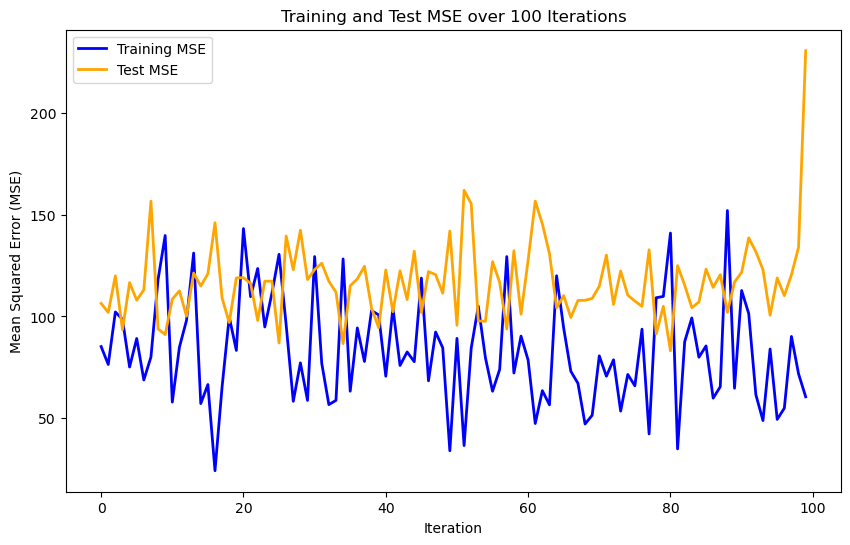

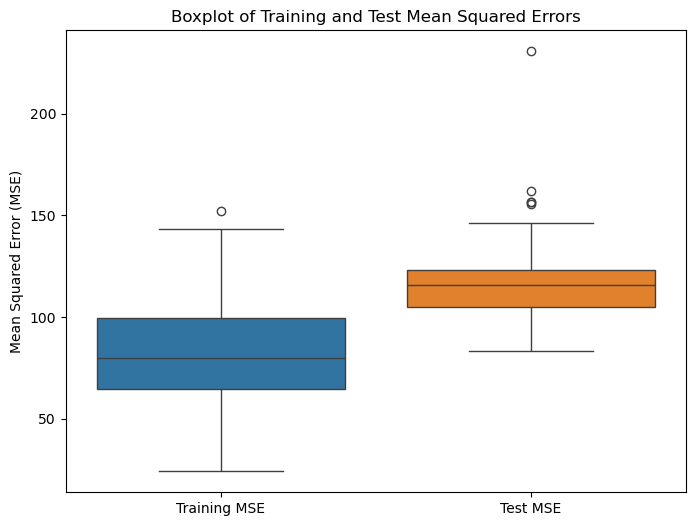

Error variance train: 704.7449148977868
Error variance test: 386.6397200928693


In [224]:
# Plot the training and test MSE over 100 iterations
plt.figure(figsize=(10, 6))
plt.plot(range(K), errors_train, label='Training MSE', color='blue', linewidth=2)
plt.plot(range(K), errors_test, label='Test MSE', color='orange', linewidth=2)
plt.title('Training and Test MSE over 100 Iterations')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

# Boxplot of the training and test MSE
plt.figure(figsize=(8, 6))
sns.boxplot(data=[errors_train, errors_test])
plt.xticks([0, 1], ['Training MSE', 'Test MSE'])
plt.title('Boxplot of Training and Test Mean Squared Errors')
plt.ylabel('Mean Squared Error (MSE)')
plt.show()

print("Error variance train:", error_variance_train)
print("Error variance test:", error_variance_test)

In [ ]:
#Write your reflections here...

# Run the cell below to plot the training and testing error values for each iteration (line plot on top), along with the mean errors for both the training and testing sets (box plot on bottom). Reflect on: 
# 1. How does the trend of the training MSE (as seen in the line plot) compare to the trend of the test MSE over the 100 iterations?
# The training MSE is generally lower than the test MSE across the 100 iterations, indicating that the model fits the training data better than it generalizes to unseen data. 
# This is expected because the model is optimized to minimize error on the training data, while the test data represents unseen data that may have different characteristics.
# The variance of the training MSE is higher than that of the test MSE, which may be due to the smaller size of the training set (M=20) compared to the test set (80 points). 
# With fewer training points, the model's performance can vary more significantly depending on which specific points are sampled in each iteration.

# 2. What role does the variance in the test MSE play in understanding the model’s robustness on unseen data?
# The variance is the measure of how much the test MSE values fluctuate across different iterations.
# A low variance in the test MSE indicates that the model performs consistently across different iterations, suggesting good robustness and generalization to unseen data. 
# Conversely, a high variance in the test MSE suggests that the model's performance is unstable and may be sensitive to the specific training samples used, indicating potential overfitting or underfitting issues.

# 3. Are there any clear outliers in the boxplot for either the mean training or test MSE? How might outliers affect your understanding of the model’s performance?
# Yes, we see those marked as small points outside the whiskers of the boxplot.
# These outliers indicate that in some iterations, the model performed significantly worse than in others.
# This could be due to the random sampling of training points that may not represent the overall data distribution well, but it could also be due to outliers in the data itself.
# Outliers can skew the mean MSE values, making it appear that the model performs worse than it typically does.

# 4. From the boxplot, do the distributions of training and test MSE overlap significantly, or are they visibly different? What does this suggest about the generalization capability of the model?
# The distributions of training and test MSE do overlap to some extent, but they are visibly different, with the training MSE generally being lower than the test MSE.
# Their upper whiskers are quite close, indicating that the worst-case training and test errors are similar.
# But the rest of the test MSE distribution is higher than the median of the training MSE distribution.
# This might again be due to the fact that the training set is much smaller than the test set, leading to higher variability in training errors.
# But it also could suggest that the model may not generalize perfectly to unseen data, as indicated by the higher test MSE values.

# 5. Based on the line plot, do any iterations show large fluctuations in the test MSE compared to the training MSE? How does this align with what you observe in the boxplot?
# Yes, there are iterations where the test MSE shows large fluctuations compared to the training MSE.
# This is also reflected in the boxplot as outliers in the test MSE distribution.

# 6. Given the boxplot’s visualization of the MSE distributions, do the whiskers (range) for the train MSE extend further than those for the test MSE? What could explain the larger variance in train errors?
# Yes, the whiskers for the training MSE do extend further than those for the test MSE (but only in the lower end), indicating a larger range of training errors.
# This could be explained by the smaller size of the training set (M=20) compared to the test set (80 points).
# With fewer training points, the model's performance can vary more significantly depending on which specific points are sampled in each iteration.

# **Hint**
# Take the size of the training and testing sets into consideration.


## Model complexity

---
**Task 5 (medium): Polynomial order👩‍💻💡**
This task experiments with fitting an increasingly more complex model to the data. The cell below performs polynomial fitting for the orders defined in the `degrees`
 array and stores the mean and variance of the training and test errors.
1. Run the cell below to visualize the mean and variance of the training and testing MSEs across different model degrees. How does increasing model complexity impact the training and testing errors?
2. Inspect the graph and identify at which degree does the model seem to overfit? Reflect on how this corresponds to the underlying function.
3. Observe how the model parameters change as the polynomial order increases. Explain the reasons for the observations on the higher-order terms.


---

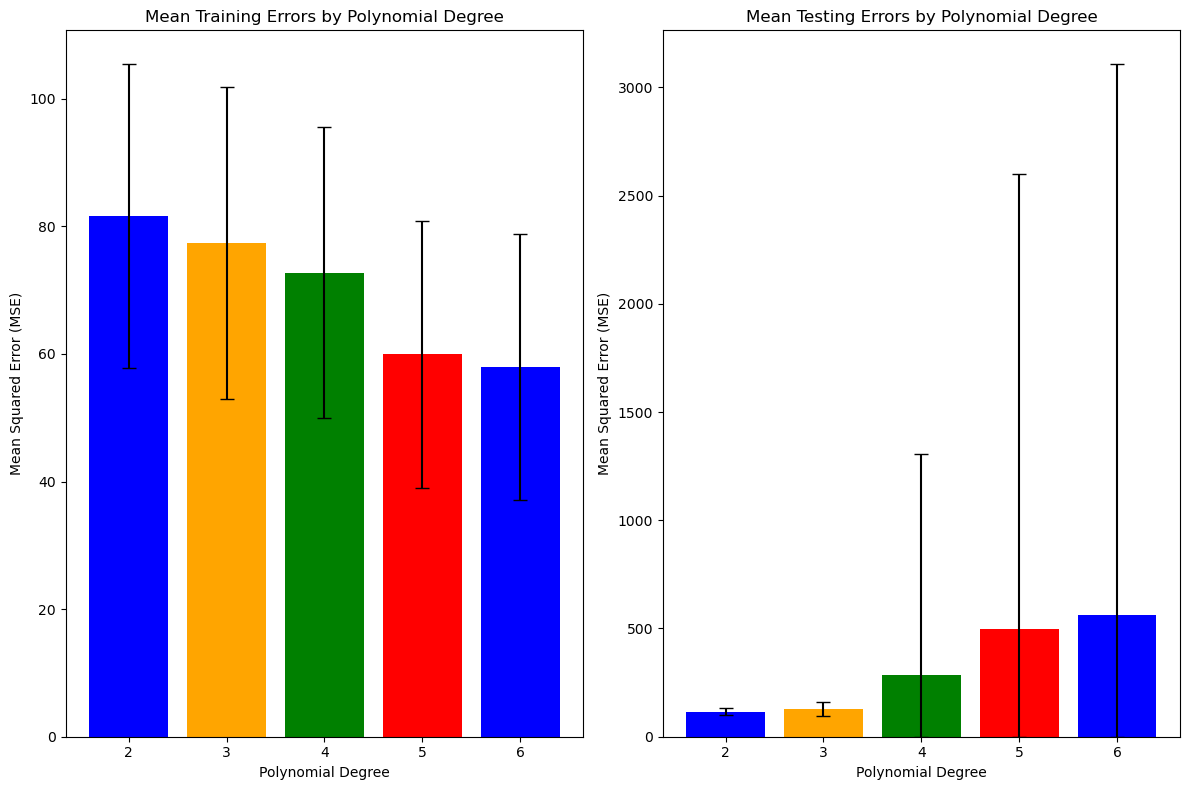

In [ ]:
degrees = [2, 3, 4, 5, 6]  # 1st, 2nd, 3rd, and 4th order polynomials

# Initialize dictionaries to store the training and test error means and variances for each degree
error_means_train = {}
error_variances_train = {}
error_means_test = {}
error_variances_test = {}

# Set parameters for sampling and fitting
M = 20  # Number of samples to use
K = 100  # Number of iterations

# Loop through each polynomial degree
for N in degrees:
    
    # Perform the iterative fitting process for the current polynomial degree
    errors_train, errors_test, _, error_mean_train, error_variance_train, error_mean_test, error_variance_test, _, _, _ = iterate_fit(x_range, y_noisy, M, N, K)
    
    # Store the results for training and test sets
    error_means_train[N] = error_mean_train
    error_variances_train[N] = error_variance_train
    error_means_test[N] = error_mean_test
    error_variances_test[N] = error_variance_test
    

# Data preparation
mean_training_errors = [error_means_train[d] for d in degrees]
mean_testing_errors = [error_means_test[d] for d in degrees]
training_error_bars = prepare_error_bars(mean_training_errors, [error_variances_train[d] for d in degrees])
testing_error_bars = prepare_error_bars(mean_testing_errors, [error_variances_test[d] for d in degrees])

colors = ['blue', 'orange', 'green', 'red']

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# Plot training errors
axes[0].bar(degrees, mean_training_errors, color=colors, yerr=training_error_bars, capsize=5)
axes[0].set_xticks(degrees)
axes[0].set_title('Mean Training Errors by Polynomial Degree')
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('Mean Squared Error (MSE)')

# Plot testing errors
axes[1].bar(degrees, mean_testing_errors, color=colors, yerr=testing_error_bars, capsize=5)
axes[1].set_xticks(degrees)
axes[1].set_title('Mean Testing Errors by Polynomial Degree')
axes[1].set_xlabel('Polynomial Degree')
axes[1].set_ylabel('Mean Squared Error (MSE)')

# Adjust layout
plt.tight_layout()
plt.show()

In [0]:
#Write your reflections here...

# This task experiments with fitting an increasingly more complex model to the data. 
# The cell below performs polynomial fitting for the orders defined in the `degrees` array and stores the mean and variance of the training and test errors.
# 1. Run the cell below to visualize the mean and variance of the training and testing MSEs across different model degrees. How does increasing model complexity impact the training and testing errors?
# The training error generally decreases as the polynomial degree increases, indicating that the model is better able to fit the training data with higher complexity.
# However, the testing error concurrently increases, indicating that the model is overfitting the training data and not generalizing well to unseen data.
# This trend suggests that while a more complex model can capture the training data more accurately, it may also capture noise and outliers, leading to poorer performance on the test set.

# 2. Inspect the graph and identify at which degree does the model seem to overfit? Reflect on how this corresponds to the underlying function.
# The model seems to overfit starting from degree 4, as indicated by the significant increase in testing error while the training error continues to decrease.
# The underlying function is a polynomial of degree 2, and since the 2. order model is not performing much worse than the higher degrees, this would also be the ideal degree to choose for fitting the data.

# 3. Observe how the model parameters change as the polynomial order increases. Explain the reasons for the observations on the higher-order terms.
# As the polynomial order increases, the model parameters (coefficients) for the higher-order terms tend to become larger in magnitude and more variable across iterations.
# This is because higher-order polynomials have more flexibility to fit the training data, which can lead to overfitting.
# The higher-order terms may capture noise and outliers in the data rather than the true underlying relationship, resulting in coefficients that are less stable and more sensitive to the specific training samples used in each iteration.


---
**Task 6 (hard): Model parameters👩‍💻💡📽️**
1. Run the cell below to fit a 5th-order polynomial to the data and visualize the covariance and correlation matrices of the model parameters. 
2. Answer the following questions:    
    - Which pairs of coefficients show high levels of covariance/correlation? 
    - What does the variance of the model parameters say about the performance? 
    - Could this suggest that some coefficients remain relatively stable across different samples?
    - What does the covariance of the model parameters reveal about the performance of the model? 
    - What does this reveal about model stability? 
    - Could this indicate overfitting or sensitivity to changes in the dataset?
    - What does the correlations between coefficients say about the redundancy of model parameters? 
    - Which model parameters contribute very little to the overall model?
    - What is the difference between the covariance and correlation when analyzing the data?




---

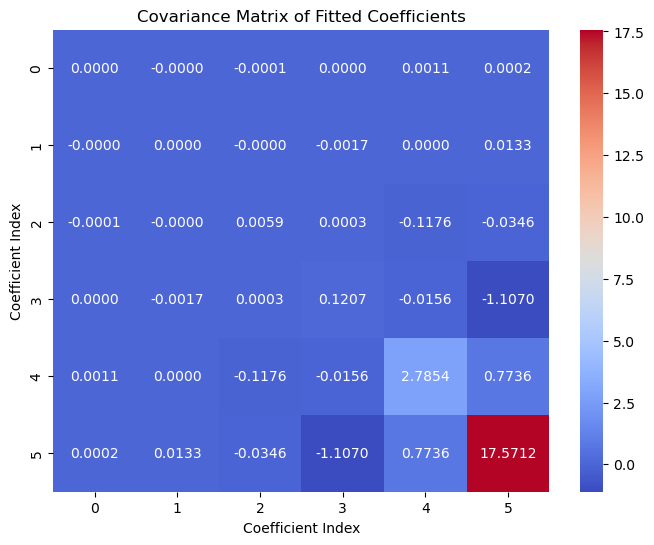

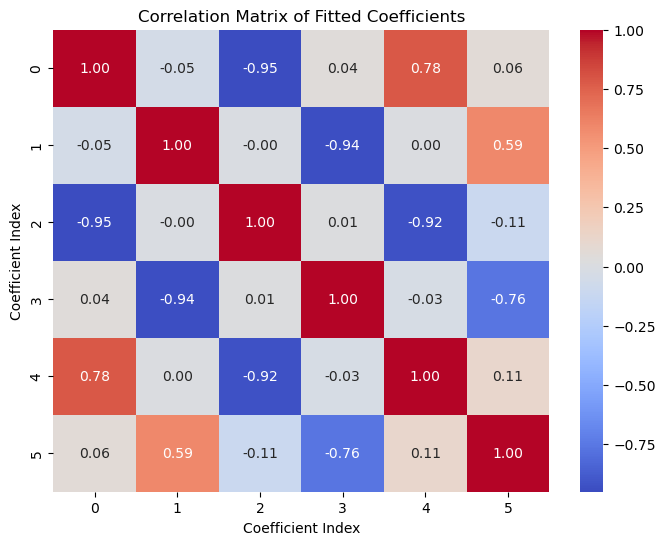

In [262]:
# Set parameters for sampling and fitting
M = 20  # Number of samples to use
K = 100  # Number of iterations
N = 5
errors_train, errors_test, coeffs_array, error_mean_train, error_variance_train, error_mean_test, error_variance_test, coeffs_mean, coeffs_covariance, coeffs_correlation = iterate_fit(x_range, y_noisy, M, N, K)

# Plot the covariance matrix of the fitted polynomial coefficients
plt.figure(figsize=(8, 6))
sns.heatmap(coeffs_covariance, annot=True, fmt='.4f', cmap='coolwarm', cbar=True)
plt.title('Covariance Matrix of Fitted Coefficients')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Index')
plt.show()

# Plot the covariance matrix of the fitted polynomial coefficients
plt.figure(figsize=(8, 6))
sns.heatmap(coeffs_correlation, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Fitted Coefficients')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Index')
plt.show()

In [0]:
#Write your reflections here...

#The above plot visualizes the covariance and correlation matrices of the the model parameters after fitting a 5th-order polynomial to the data.

# 2. Answer the following questions:    
#  - Which pairs of coefficients show high levels of covariance/correlation? 
# Several pairs show very strong (anti-)correlation:
# Coefficient 0 & 2: ≈ −0.95
# Coefficient 1 & 3: ≈ −0.94
# Coefficient 2 & 4: ≈ −0.92
# Coefficient 0 & 4: ≈ +0.78
# Coefficient 3 & 5: ≈ −0.76
# These values are close to ±1, indicating strong dependence between parameters.

#  - What does the variance of the model parameters say about the performance? 
# The diagonal values represent the variance of each coefficient:
# Coefficients 0 and 1: variance ≈ 0
# Coefficient 2: variance ≈ 0.006
# Coefficient 3: variance ≈ 0.12
# Coefficient 4: variance ≈ 2.79
# Coefficient 5: variance ≈ 17.57

# Lower-order terms (0–2) are very stable and well constrained by the data.
# Higher-order terms (4–5) have extremely large variance, meaning they are highly unstable and change significantly across different samples.
# This indicates that the data strongly supports only the lower-order structure.

#  - Could this suggest that some coefficients remain relatively stable across different samples?
# Yes.
# Coefficients with low variance and weaker correlations are more stable (since they depend less on other parameters).
# In polynomial models, these are usually the lower-order terms (e.g., constant and linear terms), and that is also the case here.
# Higher-order terms tend to fluctuate more across samples due to their sensitivity to noise and overfitting.

#  - What does the covariance of the model parameters reveal about the performance of the model? 
# The erformance of the model is influenced by how well the parameters are estimated from the data.
# High covariance between parameters indicates that they are not independently estimated, which can lead to instability in the model.
# This instability can result in large changes in the fitted model for small changes in the data, reducing the model's reliability and predictive power, as noise and outliers can gain more influence.

#  - What does this reveal about model stability? 
# High covariance between coefficients indicates that changes in one parameter are associated with changes in another.
# This suggests that the model parameters are not independent and that the model may be over-parameterized for the given data.
# The presence of strong covariance can lead to instability in the fitted model, as small changes in the data can cause large shifts in the coefficients.

#  - Could this indicate overfitting or sensitivity to changes in the dataset?
# Yes.
# Strong covariance and correlation between parameters often indicate that the model is overfitting the training data.
# Overfitting occurs when the model captures noise and outliers in the data rather than the true underlying relationship.
# This can lead to sensitivity to changes in the dataset, where small variations in the data can result in significant changes in the fitted model.

#  - What does the correlations between coefficients say about the redundancy of model parameters? 
# Strong correlations (close to ±1) indicate that parameters explain the same variation, 
# meaning multiple coefficients are effectively interchangeable.
# It indicate parameter redundancy, where several coefficients are explaining the same structure in the data 
# and the model has more degrees of freedom than the data can support.
# So different model parameters end up being strongly linked to each other (e.g., if one increases, another decreases to compensate).

#  - Which model parameters contribute very little to the overall model?
# The higher-order coefficients (coefficients 4 and 5) contribute very little to the overall model.
# This is indicated by their high variance and strong correlations with other coefficients, 
# suggesting they are not well constrained by the data and may be capturing noise rather than meaningful patterns.
# Their effect is unstable and inconsistent across samples and they contribute little reliable information.

#  - What is the difference between the covariance and correlation when analyzing the data?
# Covariance identifies unstable parameters (high variance).
# Correlation identifies dependent or redundant parameters (high correlation).

